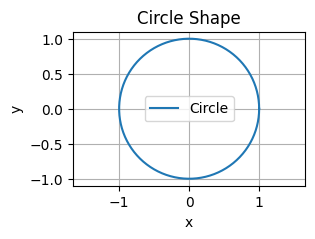

In [1]:
import numpy as np

import matplotlib.pyplot as plt

# Define the circle parameters
radius = 1
theta = np.linspace(0, 2 * np.pi, 100)

# Parametric equations for the circle
x = radius * np.cos(theta)
y = radius * np.sin(theta)

# Plot the circle
plt.figure(figsize=(3, 2))
plt.plot(x, y, label="Circle")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Circle Shape")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

Plotting Fourier series for square wave:


C:\Users\Apurbo\AppData\Local\Temp\ipykernel_17056\244946739.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  a0 = (1 / (2 * self.L)) * np.trapz(fx, x)
C:\Users\Apurbo\AppData\Local\Temp\ipykernel_17056\244946739.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  an = (1 / self.L) * np.trapz(fx * cos_term, x)
C:\Users\Apurbo\AppData\Local\Temp\ipykernel_17056\244946739.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bn = (1 / self.L) * np.trapz(fx * sin_term, x)


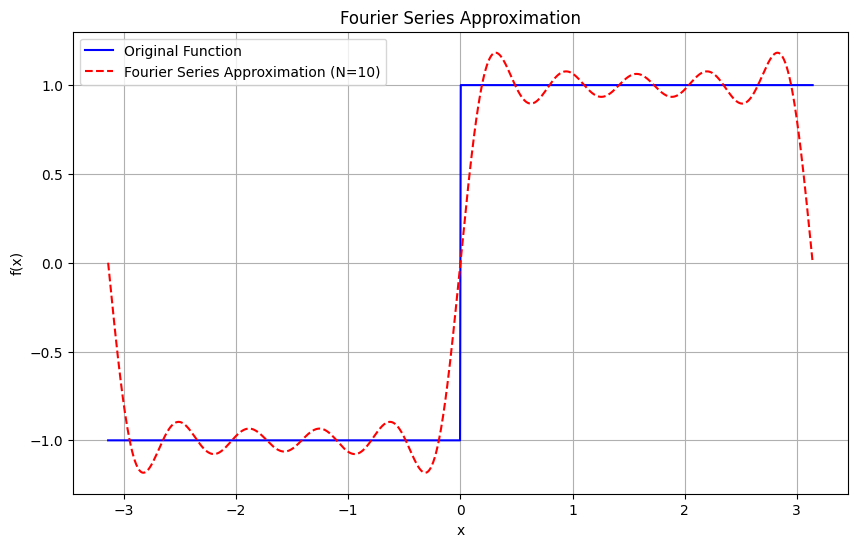

Plotting Fourier series for sawtooth wave:


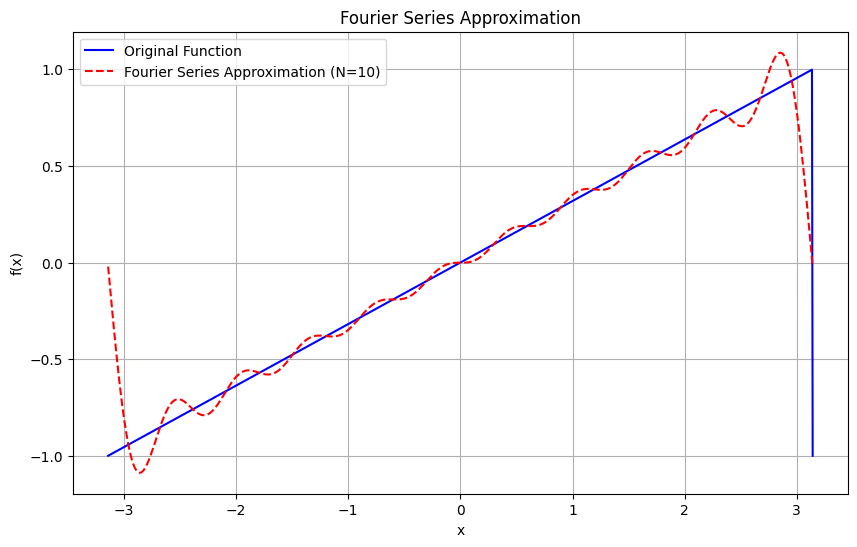

Plotting Fourier series for triangle wave:


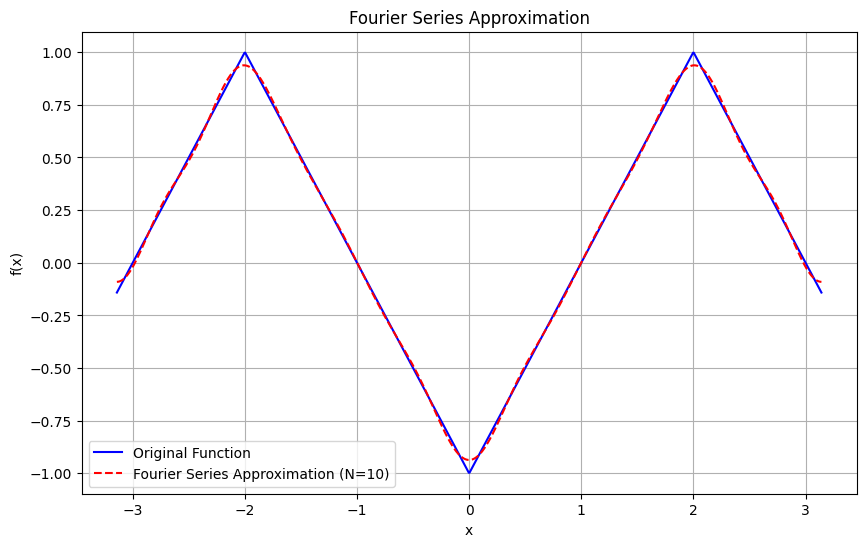

Plotting Fourier series for sine wave:


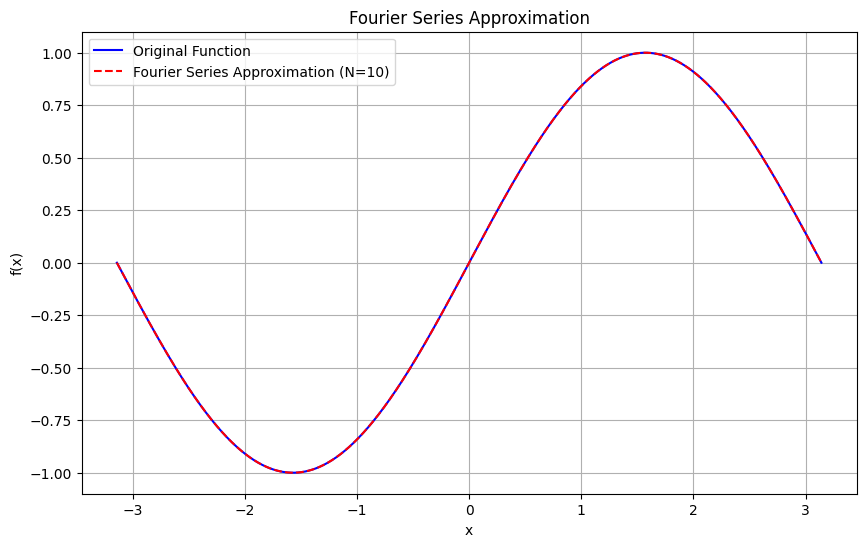

Plotting Fourier series for cosine wave:


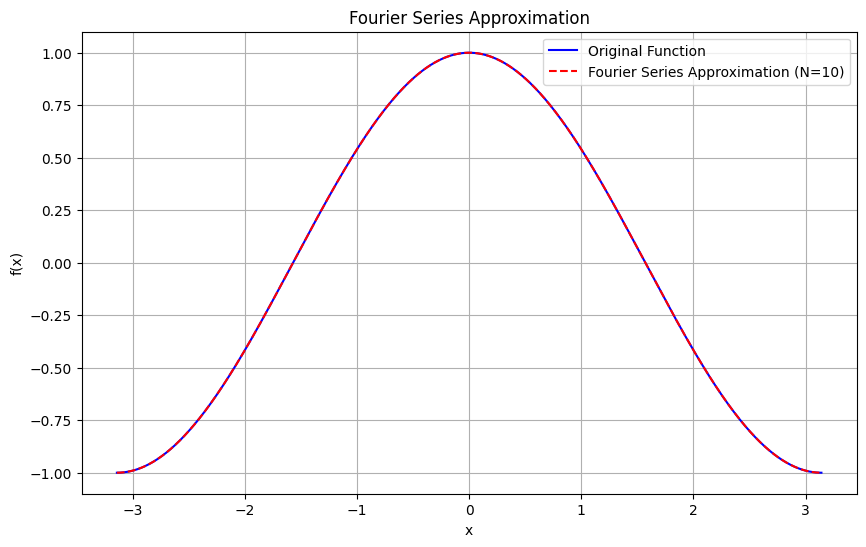

In [2]:
import numpy as np
import matplotlib.pyplot as plt


class FourierSeries:
    def __init__(self, func, L, terms=10):
        """
        Initialize the FourierSeries class with a target function, period L, and number of terms.

        Parameters:
        - func: The target function to approximate.
        - L: Half the period of the target function.
        - terms: Number of terms to use in the Fourier series expansion.
        """
        self.func = func
        self.L = L
        self.terms = terms

    def calculate_a0(self, N=1000):
        """
        Compute the a0 coefficient, which is the average (DC component) of the function over one period.
        """
        x = np.linspace(-self.L, self.L, N)
        fx = self.func(x)
        a0 = (1 / (2 * self.L)) * np.trapz(fx, x)
        return a0

    def calculate_an(self, n, N=1000):
        """
        Compute the an coefficient for the nth cosine term in the Fourier series.
        """
        x = np.linspace(-self.L, self.L, N)
        fx = self.func(x)
        cos_term = np.cos(n * np.pi * x / self.L)
        an = (1 / self.L) * np.trapz(fx * cos_term, x)
        return an

    def calculate_bn(self, n, N=1000):
        """
        Compute the bn coefficient for the nth sine term in the Fourier series.
        """
        x = np.linspace(-self.L, self.L, N)
        fx = self.func(x)
        sin_term = np.sin(n * np.pi * x / self.L)
        bn = (1 / self.L) * np.trapz(fx * sin_term, x)
        return bn

    def approximate(self, x):
        """
        Use the calculated coefficients to build the Fourier series approximation.
        """
        a0 = self.calculate_a0()
        approximation = a0  # Initialize with a0/2 term

        for n in range(1, self.terms + 1):
            an = self.calculate_an(n)
            bn = self.calculate_bn(n)
            approximation += an * np.cos(n * np.pi * x / self.L) + bn * np.sin(
                n * np.pi * x / self.L
            )

        return approximation

    def plot(self):
        """
        Plot the original function and its Fourier series approximation.
        """
        x = np.linspace(-self.L, self.L, 1000)
        original = self.func(x)
        approximation = self.approximate(x)

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(x, original, label="Original Function", color="blue")
        plt.plot(
            x,
            approximation,
            label=f"Fourier Series Approximation (N={self.terms})",
            color="red",
            linestyle="--",
        )
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.title("Fourier Series Approximation")
        plt.grid(True)
        plt.show()


def target_function(x, function_type="square"):
    """
    Defines various periodic target functions that can be used for Fourier series approximation.
    """
    if function_type == "square":
        return np.where(np.sin(x) >= 0, 1, -1)

    elif function_type == "sawtooth":
        return ((x - np.pi) % (2 * np.pi)) / np.pi - 1

    elif function_type == "triangle":
        # return np.abs(((x - np.pi) % (2 * np.pi)) / np.pi - 1) * 2 - 1
        return 1-np.abs((x%4)-2)

    elif function_type == "sine":
        return np.sin(x)

    elif function_type == "cosine":
        return np.cos(x)

    else:
        raise ValueError(
            "Invalid function_type. Choose from 'square', 'sawtooth', 'triangle', 'sine', or 'cosine'."
        )


# Example of using these functions in the FourierSeries class
if __name__ == "__main__":
    L = np.pi  # Half-period for all functions
    terms = 10  # Number of terms in Fourier series

    # Test each type of target function
    for function_type in ["square", "sawtooth", "triangle", "sine", "cosine"]:
        print(f"Plotting Fourier series for {function_type} wave:")

        # Define the target function dynamically
        fourier_series = FourierSeries(
            lambda x: target_function(x, function_type=function_type), L, terms
        )

        # Plot the Fourier series approximation
        fourier_series.plot()

In [3]:
import numpy as np

# Define the x values from 0 to 3, with 100 points
x = np.linspace(0, 3, 100)

# Define the function y = x^2 at each x
y = x**2

# Calculate the integral (area under the curve) using np.trapz
integral = np.trapz(y, x)

print(f"The approximate integral of y = x^2 from 0 to 3 is: {integral}")

The approximate integral of y = x^2 from 0 to 3 is: 9.000459136822775


C:\Users\Apurbo\AppData\Local\Temp\ipykernel_17056\3760142813.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(y, x)


Plotting Fourier series for square wave:


C:\Users\Apurbo\AppData\Local\Temp\ipykernel_17056\3096143066.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  a0 = (1 / self.L) * np.trapz(fx, x)
C:\Users\Apurbo\AppData\Local\Temp\ipykernel_17056\3096143066.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  an = (1 / self.L) * np.trapz(fx * cos_func, x)
C:\Users\Apurbo\AppData\Local\Temp\ipykernel_17056\3096143066.py:76: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bn = (1 / self.L) * np.trapz(fx * sin_func, x)


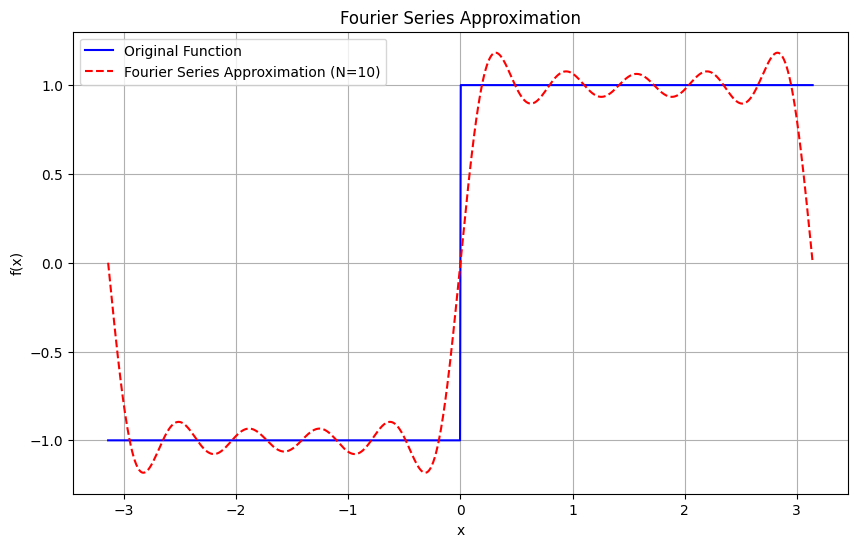

Plotting Fourier series for sawtooth wave:


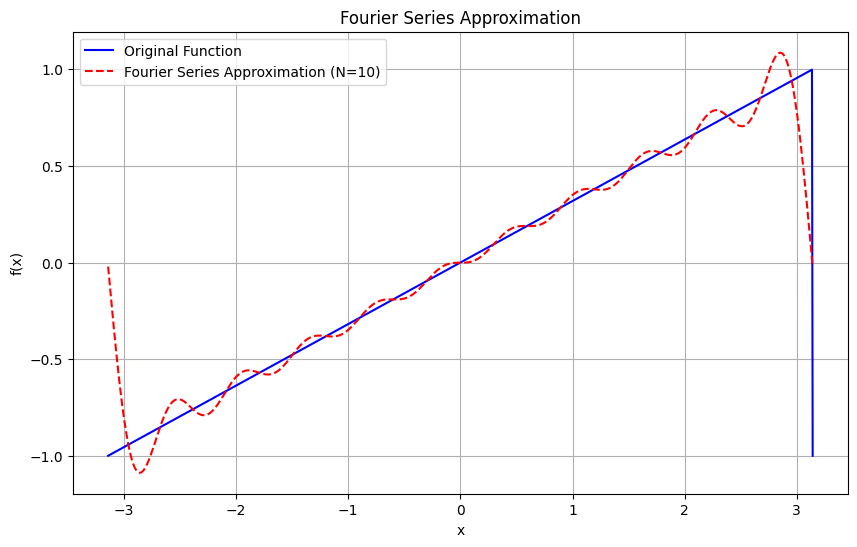

Plotting Fourier series for triangle wave:


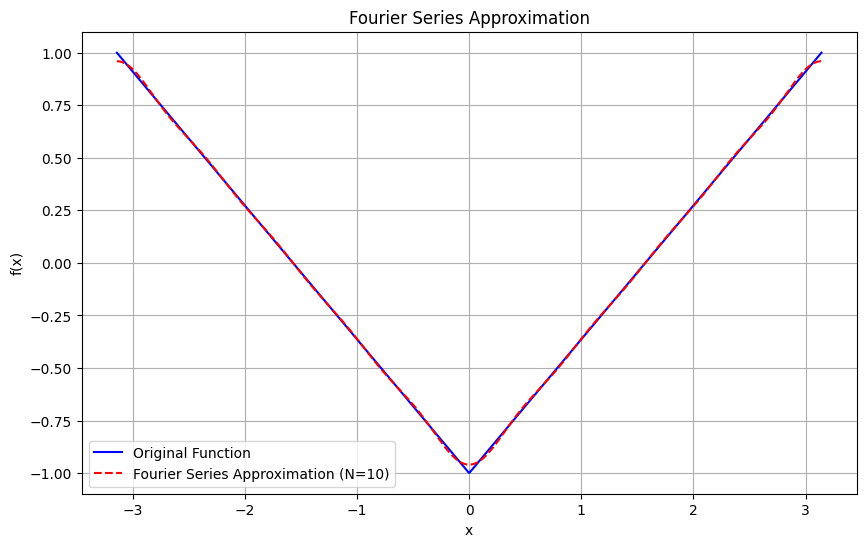

Plotting Fourier series for sine wave:


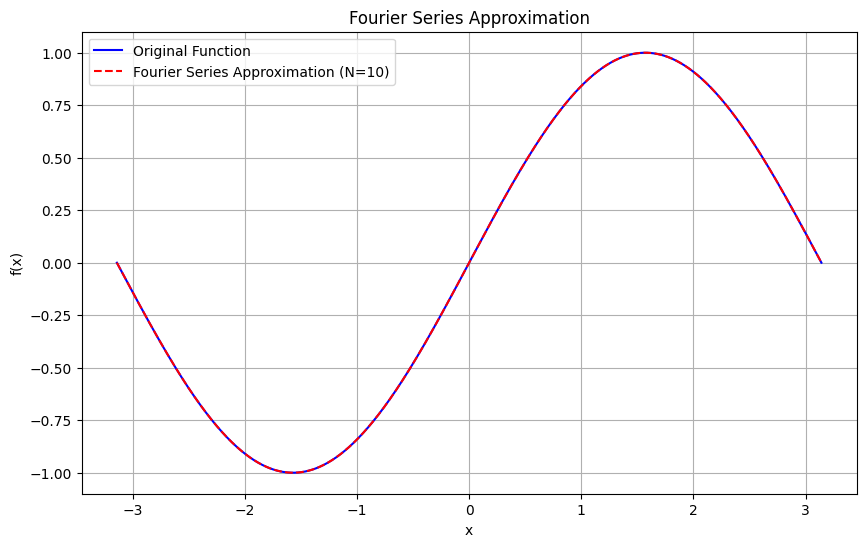

Plotting Fourier series for cosine wave:


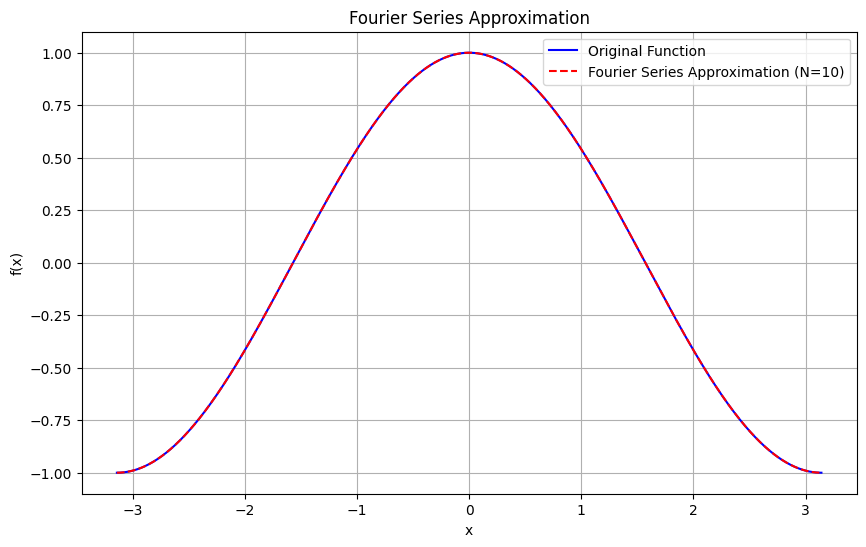

In [4]:
import numpy as np
import matplotlib.pyplot as plt


class FourierSeries:
    def __init__(self, func, L, terms=10):
        """
        Initialize the FourierSeries class with a target function, period L, and number of terms.

        Parameters:
        - func: The target function to approximate.
        - L: Half the period of the target function.
        - terms: Number of terms to use in the Fourier series expansion.
        """
        self.func = func
        self.L = L
        self.terms = terms

    def calculate_a0(self, N=1000):
        """
        Step 1: Compute the a0 coefficient, which is the average (DC component) of the function over one period.

        You need to integrate the target function over one period from -L to L.
        For that, you can use the trapezoidal rule with a set of points (N points here) for numerical integration.

        Parameters:
        - N: Number of points to use for integration (more points = more accuracy).

        Returns:
        - a0: The computed a0 coefficient.
        """
        x = np.linspace(-self.L, self.L, N)
        fx = self.func(x)
        a0 = (1 / self.L) * np.trapz(fx, x)

        return a0

    def calculate_an(self, n, N=1000):
        """
        Step 2: Compute the an coefficient for the nth cosine term in the Fourier series.

        You need to integrate the target function times cos(n * pi * x / L) over one period.
        This captures how much of the nth cosine harmonic is present in the function.

        Parameters:
        - n: Harmonic number to calculate the nth cosine coefficient.
        - N: Number of points to use for numerical integration.

        Returns:
        - an: The computed an coefficient.
        """
        x = np.linspace(-self.L, self.L, N)
        fx = self.func(x)
        cos_func = np.cos((n * np.pi * x) / self.L)
        an = (1 / self.L) * np.trapz(fx * cos_func, x)

        return an

    def calculate_bn(self, n, N=1000):
        """
        Step 3: Compute the bn coefficient for the nth sine term in the Fourier series.

        You need to integrate the target function times sin(n * pi * x / L) over one period.
        This determines the contribution of the nth sine harmonic in the function.

        Parameters:
        - n: Harmonic number to calculate the nth sine coefficient.
        - N: Number of points to use for numerical integration.

        Returns:
        - bn: The computed bn coefficient.
        """
        x = np.linspace(-self.L, self.L, N)
        fx = self.func(x)
        sin_func = np.sin((n * np.pi * x) / self.L)
        bn = (1 / self.L) * np.trapz(fx * sin_func, x)

        return bn

    def approximate(self, x):
        """
        Step 4: Use the calculated coefficients to build the Fourier series approximation.

        For each term up to the specified number of terms, you need to calculate the sum of:
        a0 (the constant term) + cosine terms (an * cos(n * pi * x / L)) + sine terms (bn * sin(n * pi * x / L)).

        Parameters:
        - x: Points at which to evaluate the Fourier series.

        Returns:
        - The Fourier series approximation evaluated at each point in x.
        """
        # Compute a0 term

        # Initialize the series with the a0 term

        # Compute each harmonic up to the specified number of terms

        a0 = self.calculate_a0()
        approximate = a0 / 2
        for n in range(1, self.terms + 1):
            an = self.calculate_an(n)
            bn = self.calculate_bn(n)
            cos_term = an * np.cos((n * np.pi * x) / self.L)
            sin_term = bn * np.sin((n * np.pi * x) / self.L)
            approximate += cos_term + sin_term

        return approximate

    def plot(self):
        """

        Step 5: Plot the original function and its Fourier series approximation.

        You need to calculate the Fourier series approximation over a set of points (x values) from -L to L.
        Then plot both the original function and the Fourier series to visually compare them.
        """
        # Generate points over one period
        # Compute original function values
        # Compute Fourier series approximation

        x = np.linspace(-self.L, self.L,1000)
        original = self.func(x)
        approximation = self.approximate(x)  # Implement this line

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(x, original, label="Original Function", color="blue")
        plt.plot(
            x,
            approximation,
            label=f"Fourier Series Approximation (N={self.terms})",
            color="red",
            linestyle="--",
        )
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.title("Fourier Series Approximation")
        plt.grid(True)
        plt.show()


def target_function(x, function_type="square"):
    """
    Defines various periodic target functions that can be used for Fourier series approximation.

    Parameters:
    - x: Array of x-values for the function.
    - function_type: Type of function to use ("square", "sawtooth", "triangle", "sine", "cosine").

    Returns:
    - The values of the specified target function at each point in x.
    """
    if function_type == "square":
        # Square wave: +1 when sin(x) >= 0, -1 otherwise

        return np.where(np.sin(x) >= 0, 1, -1)

    elif function_type == "sawtooth":
        # Sawtooth wave: linearly increasing from -1 to 1 over the period

        return 2 * (x / (2 * np.pi) - np.floor(0.5 + x / (2 * np.pi)))


    elif function_type == "triangle":
        # Triangle wave: periodic line with slope +1 and -1 alternately

        return np.abs(((x - np.pi) % (2 * np.pi)) / np.pi - 1) * 2 - 1

    elif function_type == "sine":
        # Pure sine wave

        return np.sin(x)

    elif function_type == "cosine":
        # Pure cosine wave

        return np.cos(x)

    else:
        raise ValueError(
            "Invalid function_type. Choose from 'square', 'sawtooth', 'triangle', 'sine', or 'cosine'."
        )


# Example of using these functions in the FourierSeries class
if __name__ == "__main__":
    L = np.pi  # Half-period for all functions
    terms = 10  # Number of terms in Fourier series

    # Test each type of target function
    for function_type in ["square", "sawtooth", "triangle", "sine", "cosine"]:
        print(f"Plotting Fourier series for {function_type} wave:")

        # Define the target function dynamically
        fourier_series = FourierSeries(
            lambda x: target_function(x, function_type=function_type), L, terms
        )

        # Plot the Fourier series approximation
        fourier_series.plot()